In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

In [2]:
sns.set_theme(style="whitegrid", context="paper")

# 1. Data Preparation

### Datasets
- *Real Datasets*
    - MIMIM-CXR (This is our reference)
    - CheXpert
- *Synthetic*
    - Cheff - 5000 images generated by a DDPM model called `Cheff`
    - Roentgen - 5000 images generated by a DDPM model called `Cheff`
> All the synthetic image pairs are generated from the identical `report/prompts`

### Anatomical Measurements
- Each image is processed via a segmentation pipeline to produce a segmentation mask.
- The segmentation mask produces binary mask for 14 anatomical regions:
    - Left Clavicle
    - Right Clavicle
    - Left Scapula
    - Right Scapula
    - Left Lung
    - Right Lung
    - Left Hilus Pulmonis 
    - Right Hilus Pulmonis
    - Heart, Aorta
    - Facies Diaphragmatica
    - Mediastinum
    - Weasand
    - Spine.
- From these anatomical masks we extract `10` anatomical measurements:
    1. Cardiothoracic Ratio (CTR)
    2. Left lugn area
    3. Right lung area
    4. Left clavicle area
    5. Right clavicle area
    6. Left scapula area 
    7. Right scapula area
    8. Trachel area
    9. Spine area
    10. Diaphragm area
> These are normalized by the total Chest area


In [3]:
measurement_df_real = pd.read_csv("morphometric_measurements_real.csv")
measurement_df_cheff = pd.read_csv("morphometric_measurements_cheff.csv")
measurement_df_roentgen = pd.read_csv("morphometric_measurements_roentgen.csv")
measurement_df_chexpert = pd.read_csv("morphometric_measurements_chexpert.csv")

### EDA 

In [4]:
print("Size MIMIC-CXR (ref) = ", len(measurement_df_real))
print("Size Chexpert = ", len(measurement_df_chexpert))  # Roentgen
print("Size Cheff = ", len(measurement_df_cheff))  # Cheff
print("Size Roentgen = ", len(measurement_df_roentgen))  # Roentgen

Size MIMIC-CXR (ref) =  15650
Size Chexpert =  10000
Size Cheff =  10000
Size Roentgen =  10000


In [5]:
measurement_df_cheff.describe()

,id,CTR,Thorax_Width,Spine_Length,Thoracic_Ref_Area,Lung_L_Area,Lung_R_Area,Clavicle_L_Area,Clavicle_R_Area,Scapula_L_Area,Scapula_R_Area,Trachea_Area,Spine_Area,Diaphragm_Area
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.000000,1.000000e+04
mean,4999.50000,0.483017,427.765100,473.873700,203207.611800,9.954510e+07,6.839310e+07,0.018193,1.970002e+04,8.070001e+05,1.137500e+06,0.034050,0.137549,9.965310e+07
std,2886.89568,0.073600,42.586656,42.993713,27880.189279,1.856242e+09,1.413298e+09,0.005954,1.970000e+06,5.463342e+07,7.371575e+07,0.007236,0.017112,1.875655e+09
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,2499.75000,0.441756,399.000000,472.000000,189504.500000,2.209375e-01,2.085304e-01,0.016120,1.400493e-02,5.132025e-02,5.404173e-02,0.031022,0.131235,1.999851e-01
50%,4999.50000,0.480080,429.000000,484.000000,206711.000000,2.435678e-01,2.297420e-01,0.019585,1.762645e-02,6.490745e-02,6.746133e-02,0.034709,0.138466,2.559610e-01
75%,7499.25000,0.522348,460.000000,490.000000,222306.000000,2.661849e-01,2.540080e-01,0.021990,2.013710e-02,7.830467e-02,7.998911e-02,0.038127,0.146095,3.167897e-01
max,9999.00000,0.877778,511.000000,505.000000,253456.000000,5.364100e+10,5.437200e+10,0.035389,1.970000e+08,5.053000e+09,6.265000e+09,0.066156,0.201666,8.075800e+10


##### Quality Control
- Since the anatomical measurement extraction utilizes a segmentaion model it causes `extreme` values when it fails.
- The segmentation model could fail is the input image is of extreme low quality (visual) or in the case of the generated images if it's blanck (when the model fails to generate an image)
- In the WASABI paper the authors addressed such cases by filtering such `trivial` failures
    > "For this analysis, we removed 180 images with a gray-matter QC score below 0.7 (below the 1.5x interquartile range from the first quartile) to ensure the credibility of SynthSeg measures. Note, we removed these low quality images because they were trivial to detect both visually and by all metrics. We focused the following analysis on high-quality synthetic images where human assessment becomes unreliable and a good quantitative metric is most needed." Page 5
- Our segmentation model doesn't provide a Quality Control score but we could use the measurement values to filter out `extreme` outliers.
- When the segmentation model fails the anatomical measurement values become very large numbers (~ $10^6$) or $0$
- We will filter out this rows and keep the rest

In [6]:
# backup the prompt column for later use (only for mimic-cxr and cheff, since roentgen and chexpert do not have the prompt column)
prompt_real = measurement_df_real["prompt"]
prompt_cheff = measurement_df_cheff["prompt"]
prompt_roentgen = measurement_df_roentgen["prompt"]

In [7]:
# filter the chexpert dataset to only include samples with "No Finding" or "Cardiomegaly" labels
measurement_df_chexpert = measurement_df_chexpert[
    (measurement_df_chexpert["No Finding"] == 1.0)
    | (measurement_df_chexpert["Cardiomegaly"] == 1.0)
]

measurement_df_chexpert_no_finding = measurement_df_chexpert[
    measurement_df_chexpert["No Finding"] == 1.0
]
measurement_df_chexpert_card = measurement_df_chexpert[
    measurement_df_chexpert["Cardiomegaly"] == 1.0
]

**Clean up**
- Since each dataset has different formats, we will keep only the anatomical measurements to have a standardized data

In [8]:
# remove chexpert columns that are not in the other datasets (the first 19 columns are the original chexpert columns, and the rest are the morphometric measurements)
measurement_df_chexpert_card = measurement_df_chexpert_card.drop(
    columns=measurement_df_chexpert_card.columns[:19].to_list()
)
measurement_df_chexpert_no_finding = measurement_df_chexpert_no_finding.drop(
    columns=measurement_df_chexpert_no_finding.columns[:19].to_list()
)

In [9]:
# Not used
columsn_to_drop = ["Thorax_Width", "Spine_Length", "Thoracic_Ref_Area"]
measurement_df_chexpert_card = measurement_df_chexpert_card.drop(
    columns=columsn_to_drop
)
measurement_df_chexpert_no_finding = measurement_df_chexpert_no_finding.drop(
    columns=columsn_to_drop
)

In [10]:
# same for mimic-cxr, cheff and roentgen (not used)
columsn_to_drop = [
    "id",
    "prompt",
    "path",
    "report",
    "class_label",
    "Thorax_Width",
    "Spine_Length",
    "Thoracic_Ref_Area",
]
measurement_df_real = measurement_df_real.drop(columns=columsn_to_drop)
measurement_df_cheff = measurement_df_cheff.drop(columns=columsn_to_drop)
measurement_df_roentgen = measurement_df_roentgen.drop(columns=columsn_to_drop)

In [11]:
measurement_df_cheff.head()

,CTR,Lung_L_Area,Lung_R_Area,Clavicle_L_Area,Clavicle_R_Area,Scapula_L_Area,Scapula_R_Area,Trachea_Area,Spine_Area,Diaphragm_Area
0,0.507353,0.213699,0.157513,0.020657,0.009194,0.055440,0.057815,0.035998,0.145062,0.403479
1,0.390887,0.227694,0.233412,0.015582,0.017769,0.035060,0.069457,0.023415,0.138219,0.361688
2,0.413534,0.227741,0.220557,0.018371,0.019234,0.066498,0.080067,0.031118,0.130362,0.271730
3,0.410088,0.298606,0.290810,0.021684,0.022453,0.054222,0.087038,0.036112,0.144161,0.124196
4,0.459658,0.247242,0.238303,0.003584,0.011567,0.062122,0.060634,0.032382,0.148613,0.334670


**Remove extreme values**

In [12]:
measurement_df_real = measurement_df_real[~(measurement_df_real > 1.0).any(axis=1)]
measurement_df_cheff = measurement_df_cheff[~(measurement_df_cheff > 1.0).any(axis=1)]
measurement_df_roentgen = measurement_df_roentgen[
    ~(measurement_df_roentgen > 1.0).any(axis=1)
]

measurement_df_real = measurement_df_real[~(measurement_df_real <= 0.0).any(axis=1)]
measurement_df_cheff = measurement_df_cheff[~(measurement_df_cheff <= 0.0).any(axis=1)]
measurement_df_roentgen = measurement_df_roentgen[
    ~(measurement_df_roentgen <= 0.0).any(axis=1)
]

In [13]:
measurement_df_chexpert_card = measurement_df_chexpert_card[
    ~(measurement_df_chexpert_card > 1.0).any(axis=1)
]
measurement_df_chexpert_no_finding = measurement_df_chexpert_no_finding[
    ~(measurement_df_chexpert_no_finding > 1.0).any(axis=1)
]

In [14]:
measurement_df_real["prompt"] = prompt_real
measurement_df_cheff["prompt"] = prompt_cheff
measurement_df_roentgen["prompt"] = prompt_roentgen

In [15]:
# How many 'no finding' and 'cardiomegaly' cases are there in the synthetic images
nofinding_cases_roentgen = measurement_df_roentgen[
    measurement_df_roentgen["prompt"].str.contains("healthy", na=False, case=False)
].drop(columns="prompt")

nofinding_cases_cheff = measurement_df_cheff[
    measurement_df_cheff["prompt"].str.contains("healthy", na=False, case=False)
].drop(columns="prompt")

cardiomegaly_cases_roentgen = measurement_df_roentgen[
    measurement_df_roentgen["prompt"].str.contains(
        "with cardiomegaly", na=False, case=False
    )
].drop(columns="prompt")

cardiomegaly_cases_cheff = measurement_df_cheff[
    measurement_df_cheff["prompt"].str.contains(
        "with cardiomegaly", na=False, case=False
    )
].drop(columns="prompt")

print("-" * 50)
print("`No finding` cases cheff = ", len(nofinding_cases_cheff))
print("-" * 50)
print("`No finding` cases roentgen = ", len(nofinding_cases_roentgen))
print("-" * 50)
print("`Cardiomegaly` cases cheff = ", len(cardiomegaly_cases_cheff))
print("-" * 50)
print("`Cardiomegaly` cases roentgen = ", len(cardiomegaly_cases_roentgen))
print("-" * 50)

--------------------------------------------------
`No finding` cases cheff =  5906
--------------------------------------------------
`No finding` cases roentgen =  5817
--------------------------------------------------
`Cardiomegaly` cases cheff =  883
--------------------------------------------------
`Cardiomegaly` cases roentgen =  926
--------------------------------------------------


In [16]:
# How many 'no finding' and 'cardiomegaly' cases are there in the `real` images
nofinding_cases_real = measurement_df_real[
    measurement_df_real["prompt"].str.contains("healthy", na=False, case=False)
].drop(columns="prompt")
cardiomegaly_cases_real = measurement_df_real[
    measurement_df_real["prompt"].str.contains(
        "with cardiomegaly", na=False, case=False
    )
].drop(columns="prompt")

print("-" * 50)
print("`No finding` in mimic-cxr = ", len(nofinding_cases_real))
print("-" * 50)
print("`Cardiomegaly` in mimic-cxr = ", len(cardiomegaly_cases_real))
print("-" * 50)
print(" `No finding` cases in chexpert = ", len(measurement_df_chexpert_no_finding))
print("-" * 50)
print(" `Cardiomegaly` cases in chexpert = ", len(measurement_df_chexpert_card))
print("-" * 50)

--------------------------------------------------
`No finding` in mimic-cxr =  9189
--------------------------------------------------
`Cardiomegaly` in mimic-cxr =  1383
--------------------------------------------------
 `No finding` cases in chexpert =  989
--------------------------------------------------
 `Cardiomegaly` cases in chexpert =  1300
--------------------------------------------------


|Set|# No finding|# Cardiomegaly|Total|
|---|-------------|-------------|----|
|MIMIC-CXR|2959|422|3381|
|CheXpert|502|669|1171|
|Cheff|2963|427|3390|
|Roentgen|2911|446|3357|

**Plot `anatomical measurement` distribution.**

In [17]:
measurement_df_real.columns

Index(['CTR', 'Lung_L_Area', 'Lung_R_Area', 'Clavicle_L_Area',
       'Clavicle_R_Area', 'Scapula_L_Area', 'Scapula_R_Area', 'Trachea_Area',
       'Spine_Area', 'Diaphragm_Area', 'prompt'],
      dtype='object')

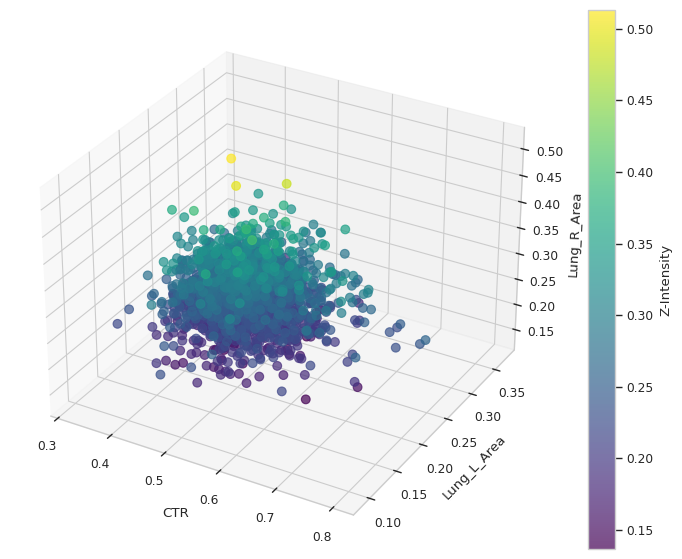

In [18]:
x = measurement_df_real['CTR'].iloc[:2000].to_numpy()
y = measurement_df_cheff['Lung_L_Area'].iloc[:2000].to_numpy()
z = measurement_df_roentgen['Lung_R_Area'].iloc[:2000].to_numpy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 'c' can be the Z array to create a color-coded depth effect
img = ax.scatter(x, y, z, c=z, cmap='viridis', marker='o', s=40, alpha=0.7)

ax.set_xlabel('CTR')
ax.set_ylabel('Lung_L_Area')
ax.set_zlabel('Lung_R_Area')
fig.colorbar(img, ax=ax, label='Z-Intensity')

fig.savefig("3d_scatter_plot.png", dpi=100, bbox_inches='tight')
plt.show()

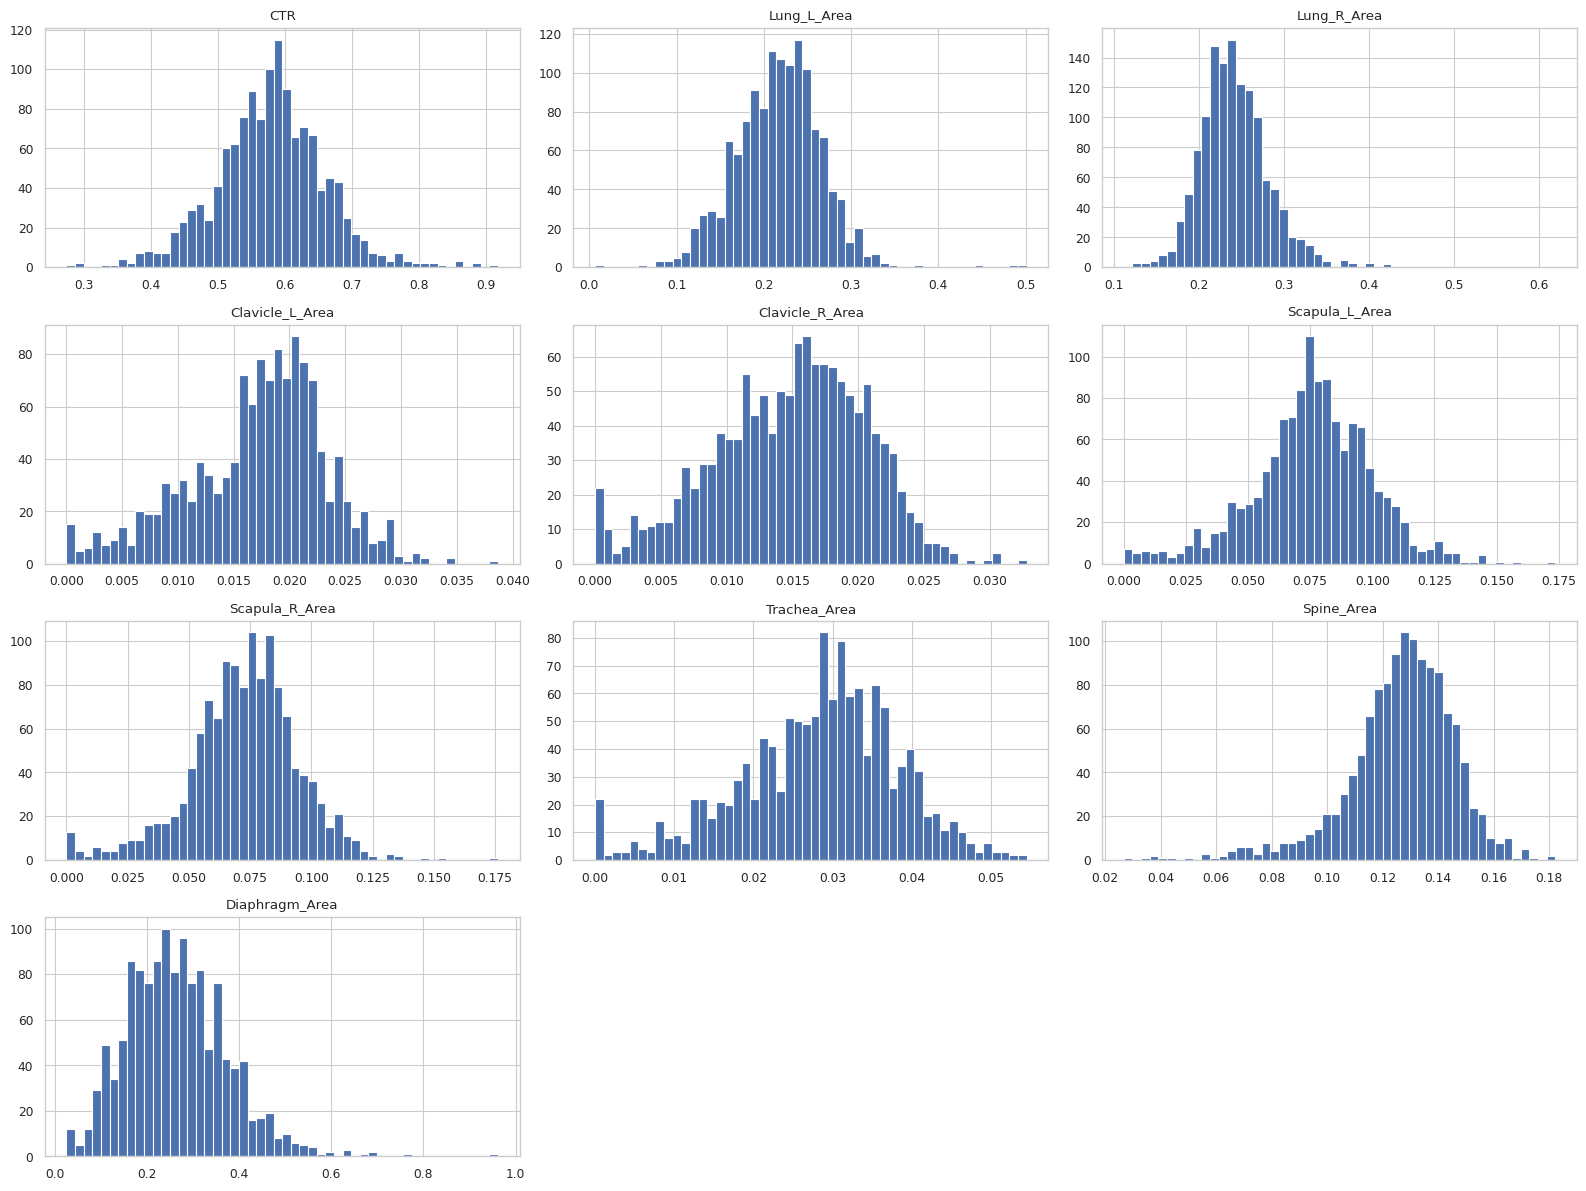

In [19]:
# plot the distribution of the features
measurement_df_chexpert_card.hist(bins=50, figsize=(16, 12), layout=(4, 3))
plt.tight_layout()

### Test for Normality (Henz-Zirkler test)

- In the WASABI paper they `assumed` the distribution of the anatomical measurements to be `Gaussian/Normal`
- This assumption is purely from `computation efficiency` case, as the `Wasserstein` distanced doen't assume Normality.
- But if the two distributions are `Normal` the  computation becomes extremely efficient.
    > From `WASABI` " ... By assuming Gaussian distributions as in FID [15], the computation of the Wasserstein distance becomes extremely efficient, as it reduces the problem to simple matrix operations without requiring iterative numerical optimization of the optimal transport problem (O(d3) complexity for computation of the square root of the covariance matrix with dimension d). This makes the distance calculation both fast and computationally scalable, especially for large-scale datasets."
- By just eyeballing our sample plot we can see that our distribution is not `normal`
- But we can still employ `Wasserstein` distance by utilizing the emperical version, the version that doesn't assume normality.
- Infact when digging through their (WASABI's) github, i found that they are using emperical `wasserstein` metrics version.[https://github.com/BahramJafrasteh/wasabi-mri/blob/main/src/metrics.py]

Let's run a normality test

In [20]:
print(pg.multivariate_normality(X=nofinding_cases_real.sample(n=400).to_numpy()))
print(pg.multivariate_normality(X=cardiomegaly_cases_real.sample(n=400).to_numpy()))
print(pg.multivariate_normality(X=nofinding_cases_cheff.sample(n=400).to_numpy()))
print(pg.multivariate_normality(X=cardiomegaly_cases_cheff.sample(n=400).to_numpy()))
print(pg.multivariate_normality(X=nofinding_cases_roentgen.sample(n=400).to_numpy()))
print(pg.multivariate_normality(X=cardiomegaly_cases_roentgen.sample(n=400).to_numpy()))

HZResults(hz=np.float64(1.2795486417889053), pval=np.float64(1.543263041806423e-160), normal=False)
HZResults(hz=np.float64(1.430040818193776), pval=np.float64(0.0), normal=False)
HZResults(hz=np.float64(1.2124303835304495), pval=np.float64(1.0656211777732632e-101), normal=False)
HZResults(hz=np.float64(1.236897314172046), pval=np.float64(6.203738517627844e-122), normal=False)
HZResults(hz=np.float64(2.096521087855509), pval=np.float64(0.0), normal=False)
HZResults(hz=np.float64(1.383355798477813), pval=np.float64(8.953448252499977e-270), normal=False)


Our data is not Normaly distributed.

In [21]:
(500**2) / 2000

125.0

# 2. Comparing the `Morphometric` Realism of Generative Models

from - [WASABI](https://papers.miccai.org/miccai-2025/paper/2013_paper.pdf)
>"...Given any two subsets of MRIs from ADNI, we randomly sampled `500` images from either subset (so that our distance estimate was not biased by sample size variations) and computed WASABI, MS-SSIM, FID, and MMD. Similar to [24], we used the 101-layer version of MedicalNet3D [8] as the feature extractor for FID and MMD computation in all experiments. In each of the four comparison scenarios, we repeated the above random sampling `1000` times to generate a distribution for the distances."

In `WASABI` they use:
- 52 volumetric measurements
- FID with MedicalNet3D backbone
- Sample size `500`
- Repeat `1000`

This experiment
- 10 area measurements
- FID with Inceptionv3 backbone
- Sample size `400`
- Repeat `1000`

In [22]:
import ot


def wasserstein_distance_pot(data1, data2, n):
    """
    Copied from WASABI-MRI Github repository
    https://github.com/BahramJafrasteh/wasabi-mri/blob/main/src/metrics.py
    """
    n_samples = n
    M = ot.dist(data1, data2)
    a = np.ones(n_samples) / n_samples
    b = np.ones(n_samples) / n_samples
    return ot.emd2(a, b, M)

In [23]:
from tqdm import tqdm


def run_nc_control(real_ctr, n_samples=400, n_repeats=1000, seed=42):
    # Control experiment: compare two random samples from the same distribution (real_ctr)
    rng = np.random.default_rng(seed)
    scores = []

    for _ in tqdm(range(n_repeats), total=n_repeats):
        sample = rng.choice(real_ctr, 2 * n_samples, replace=False)
        r1, r2 = sample[:n_samples], sample[n_samples:]
        # scores.append(sinkhorn_distance(torch.tensor(r1), torch.tensor(r2)))
        scores.append(wasserstein_distance_pot(r1, r2, n_samples))

    return np.array(scores)

In [24]:
def run_ctr_wasabi(real_ctr, synth_ctr, n_samples=400, n_repeats=1000, seed=42):
    # Compare two random samples from the real and synthetic distributions
    rng = np.random.default_rng(seed)
    scores = []

    for _ in tqdm(range(n_repeats), total=n_repeats):
        r = rng.choice(real_ctr, n_samples, replace=False)
        s = rng.choice(synth_ctr, n_samples, replace=False)
        # scores.append(sinkhorn_distance(torch.tensor(r), torch.tensor(s)))
        scores.append(wasserstein_distance_pot(r, s, n_samples))

    return np.array(scores)

Prepare data for the experiment (to numpy array)

In [25]:
real_no_finding_ctr = (
    nofinding_cases_real.to_numpy()
)  # CTR for all 'no finding' cases in the real dataset
real_cardiomegaly_ctr = (
    cardiomegaly_cases_real.to_numpy()
)  # CTR for all 'cardiomegaly' cases in the real dataset

cheff_no_finding_ctr = (
    nofinding_cases_cheff.to_numpy()
)  # CTR for all 'no finding' cases in the cheff dataset
cheff_cardiomegaly_ctr = (
    cardiomegaly_cases_cheff.to_numpy()
)  # CTR for all 'no finding' cases in the cheff dataset

roentgen_no_finding_ctr = (
    nofinding_cases_roentgen.to_numpy()
)  # CTR for all 'no finding' cases in the cheff dataset
roentgen_cardiomegaly_ctr = (
    cardiomegaly_cases_roentgen.to_numpy()
)  # CTR for all 'no finding' cases in the cheff dataset

chexpert_no_finding = measurement_df_chexpert_no_finding.to_numpy()
chexpert_card = measurement_df_chexpert_card.to_numpy()

#### Run the experiment
- `nc`: normal control (CTR value of `no-finding` split from the reference data (MIMIC-CXR))

In [26]:
n = 200
nc_vs_nc = run_nc_control(real_no_finding_ctr)  # control experiments for no finding
c_vs_c = run_ctr_wasabi(
    real_cardiomegaly_ctr,
    real_cardiomegaly_ctr,
    # n_samples=real_cardiomegaly_ctr.shape[0],
    n_samples=n,
)  # control experiments for cardiomegaly
nc_vs_c = run_ctr_wasabi(
    real_no_finding_ctr,
    real_cardiomegaly_ctr,
    # n_samples=min(real_no_finding_ctr.shape[0], real_cardiomegaly_ctr.shape[0]),
    n_samples=n,
)  # comparing no finding vs cardiomegaly in the real dataset

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 337.83it/s]


In [27]:
n = 150
nc_vs_nc_cheff = run_ctr_wasabi(
    real_no_finding_ctr,
    cheff_no_finding_ctr,
    # n_samples=min(real_no_finding_ctr.shape[0], cheff_no_finding_ctr.shape[0]),
    n_samples=n,
)
nc_vs_nc_roentgen = run_ctr_wasabi(
    real_no_finding_ctr,
    roentgen_no_finding_ctr,
    # n_samples=min(real_no_finding_ctr.shape[0], roentgen_no_finding_ctr.shape[0]),
    n_samples=n,
)

nc_vs_c_cheff = run_ctr_wasabi(
    real_no_finding_ctr,
    cheff_cardiomegaly_ctr,
    # n_samples=min(real_no_finding_ctr.shape[0], cheff_cardiomegaly_ctr.shape[0]),
    n_samples=n,
)
nc_vs_c_roentgen = run_ctr_wasabi(
    real_no_finding_ctr,
    roentgen_cardiomegaly_ctr,
    # n_samples=min(real_no_finding_ctr.shape[0], roentgen_cardiomegaly_ctr.shape[0]),
    n_samples=n,
)

c_real_vs_c_cheff = run_ctr_wasabi(
    real_cardiomegaly_ctr,
    cheff_cardiomegaly_ctr,
    # n_samples=min(real_cardiomegaly_ctr.shape[0], cheff_cardiomegaly_ctr.shape[0]),
    n_samples=n,
)
c_real_vs_c_roentgen = run_ctr_wasabi(
    real_cardiomegaly_ctr,
    roentgen_cardiomegaly_ctr,
    # n_samples=min(real_cardiomegaly_ctr.shape[0], roentgen_cardiomegaly_ctr.shape[0]),
    n_samples=n,
)

c_real_vs_c_chexpert = run_ctr_wasabi(real_cardiomegaly_ctr, chexpert_card, n_samples=n)
nc_vs_nc_chexpert = run_ctr_wasabi(
    real_no_finding_ctr, chexpert_no_finding, n_samples=n
)

nc_vs_c_chexpert = run_ctr_wasabi(real_no_finding_ctr, chexpert_no_finding, n_samples=n)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 693.40it/s]


In [28]:
# create a dataframe to store the results of the comparisons (for plotting convinience)
comparison_df = pd.DataFrame(
    {
        "real_vs_real_no_finding": nc_vs_nc,
        "real_vs_real_cardiomegaly": c_vs_c,
        "real_no_finding_vs_real_cardiomegaly": nc_vs_c,
        "real_vs_cheff_no_finding": nc_vs_nc_cheff,
        "real_vs_roentgen_no_finding": nc_vs_nc_roentgen,
        "real_no_finding_vs_cheff_cardiomegaly": nc_vs_c_cheff,
        "real_no_finding_vs_roentgen_cardiomegaly": nc_vs_c_roentgen,
        "real_vs_cheff_cardiomegaly": c_real_vs_c_cheff,
        "real_vs_roentgen_cardiomegaly": c_real_vs_c_roentgen,
        "real_vs_chexpert_no_finding": nc_vs_nc_chexpert,
        "real_vs_chexpert_cardiomegaly": c_real_vs_c_chexpert,
    }
)

### Load results of the other metrics.

Load FID scores

In [29]:
import json

with open("fid_results.json", "r") as f:
    fid_results = json.load(f)

Load MS-SSIM scores

In [30]:
with open("msssim_results.json", "r") as f:
    mssim_results = json.load(f)
mssim_results.keys()

dict_keys(['real_vs_chexpert__no_finding', 'real_vs_cheff__no_finding', 'real_vs_roentgen__no_finding', 'real_vs_cheff__cardiomegaly', 'real_vs_roentgen__cardiomegaly', 'real_vs_real__no_finding', 'real_vs_real__cardiomegaly', 'real_vs_real__no_finding_cardiomegaly', 'real_vs_cheff__no_finding_cardiomegaly', 'real_vs_roentgen__no_finding_cardiomegaly', 'real_vs_chexpert__cardiomegaly'])

Load BiomedVIL scores

> Since `CheXpert` dataset doesn't have a clincal report with it, i didn't run `prompt/image` alignment for it.

In [31]:
with open("biomedvil_results.json", "r") as f:
    biomedvil_results = json.load(f)
biomedvil_results.keys()

dict_keys(['real_vs_real__no_finding_cardiomegaly', 'real__no_finding', 'real__cardiomegaly', 'cheff__no_finding', 'cheff__cardiomegaly', 'roentgen__no_finding', 'roentgen__cardiomegaly', 'real_vs_cheff__no_finding', 'real_vs_cheff__cardiomegaly', 'real_vs_roentgen__no_finding', 'real_vs_roentgen__cardiomegaly', 'real_vs_cheff__no_finding_cardiomegaly', 'real_vs_roentgen__no_finding_cardiomegaly'])

### Within Group (real) - Between conditions (Nofinding vs Cardiomegaly)

> from WASABI - `... Therefore, before investigating the morphometric plausibility of synthetic MRIs, we first validated the soundness of our metric in a
controlled scenario based on real data.`

- Here i choose `cardiomegaly` as a control, since it is known to affect the size of the `heart`
    - Expect to see a differnce (in atleast `CTR` feature.)

>Note: Metrics score Interpretations
- `WASABI`: Smaller values -> Smaller Distance -> Better
- `FID`: Smaller values -> Smaller Distance -> Better
- `MS-SSIM`: larger values -> two-images structuraly more similar -> Better
- `Biomed-VIL`: larger values -> image aligns closely with a prompt -> Better

In [32]:
plt.rcParams.update({
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

In [33]:
from matplotlib.patches import Patch

colors = sns.color_palette("tab10", n_colors=3)

legend_elements = [
    Patch(facecolor=colors[0], label="NF_R1 vs NF_R1"),
    Patch(facecolor=colors[1], label="NF_R1 vs CM_R1"),
    Patch(facecolor=colors[2], label="NF_R1 vs NF_R2")
]

[] []


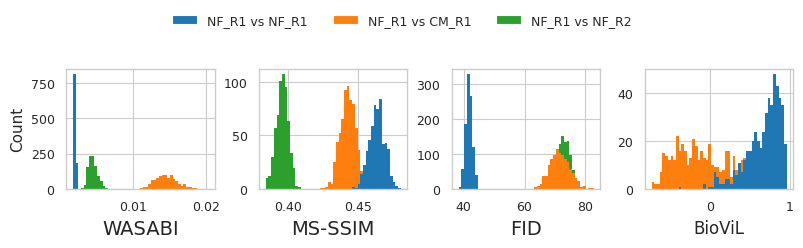

In [34]:
# WASABI
wasabi_df = comparison_df[
    [
        "real_vs_real_no_finding",
        "real_no_finding_vs_real_cardiomegaly",
        "real_vs_chexpert_no_finding",
    ]
].rename(
    columns={
        "real_vs_real_no_finding": "NF_R1 vs NF_R1",
        "real_no_finding_vs_real_cardiomegaly": "NF_R1 vs CM_R1",
        "real_vs_chexpert_no_finding": "NF_R1 vs NF_R2",
    }
)

# FID
fid_df = pd.DataFrame(
    {
        "NF_R1 vs NF_R1": fid_results["real_vs_real__no_finding"]["fid_scores"],
        "NC_R1 vs CM_R1": fid_results["real_vs_real__no_finding_cardiomegaly"][
            "fid_scores"
        ],
        "NF_R1 vs NF_R2": fid_results["real_vs_chexpert__no_finding"]["fid_scores"],
    }
)
ms_ssim_df = pd.DataFrame(
    {
        "NF_R1 vs NF_R1": mssim_results["real_vs_real__no_finding"]["ms_ssim_scores"],
        "NF_R1 vs CM_R1": mssim_results["real_vs_real__no_finding_cardiomegaly"][
            "ms_ssim_scores"
        ],
        "NF_R1 vs NF_R2": mssim_results["real_vs_chexpert__no_finding"][
            "ms_ssim_scores"
        ],
    }
)

biomed_vil_df = pd.DataFrame(
    {
        "NF_R1 vs NF_R1": biomedvil_results["real__no_finding"]["clip_scores"][:500],
        "NF_R1 vs CM_R1": biomedvil_results["real_vs_real__no_finding_cardiomegaly"][
            "clip_scores"
        ][:500],
    }
)

fig, axs = plt.subplots(1, 4, figsize=(8.2, 2.2))
plt.rcParams.update({"font.size": 12})
# =====================
# TOP ROW — Distributions
# =====================
palette = "tab10"

# # WASABI histograms
sns.histplot(
    wasabi_df,
    bins=50,
    ax=axs[0],
    palette=palette,
    log_scale=False,
    legend=False,
    linewidth=0,
    alpha=1,
)
axs[0].set_xlabel("WASABI", fontsize=14, style="normal")
# axs[0].set_title("Wasserstein", fontsize=14, style="oblique")

# msssim histograms
sns.histplot(
    ms_ssim_df,
    bins=50,
    ax=axs[1],
    palette=palette,
    log_scale=False,
    legend=False,
    linewidth=0,
    alpha=1,
)
axs[1].set_xlabel("MS-SSIM", fontsize=14, style="normal")
axs[1].set_ylabel("")

# # FID histograms
sns.histplot(
    fid_df,
    bins=50,
    ax=axs[2],
    palette=palette,
    log_scale=False,
    legend=False,
    linewidth=0,
    alpha=1,
)
axs[2].set_xlabel("FID", fontsize=14, style="normal")
axs[2].set_ylabel("")

sns.histplot(
    biomed_vil_df,
    bins=50,
    ax=axs[3],
    palette=palette,
    log_scale=False,
    legend=False,
    linewidth=0,
    alpha=1,
)
axs[3].set_xlabel("BioViL", fontsize=12, style="normal")
axs[3].set_ylabel("")

handles, labels = axs[0].get_legend_handles_labels()
print(handles, labels)
#axs[0].legend_.remove()

fig.legend(
    handles = legend_elements,
    loc='upper center',
    ncol=3,
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, 1.15)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(wspace=0.3)
plt.savefig("sanity_check.pdf", format="pdf", bbox_inches="tight")
plt.show()

- When comparing real images against themselves (NC vs NC), the WASABI distance concentrates near zero with low variance.
- In contrast, comparisons between clinically distinct subsets (NC vs Cardiomegaly) yield consistently larger distances with minimal overlap.
- This behaviour matches the expected ordering reported in the WASABI paper.
- WASABI also indicates what we expect to see, i.e two NC images from differnt real datasets are closer to each other.
- FID also shows similar trend but with significant overlap between Chexpert and Cardiomegaly cases.
- MS-SSIM incorrectly ranks cross dataset similarity higher than internal splits.
- BiomedVIL shows seperation with smaller ovelap. but high variance.

> The metric (WASABI) performs as expected on the control data (real)

> What do we get when we compare the synthetic data (nofinding and cardiomegaly) to the control (real-nofinding)

**Is the difference Significant**

In [35]:
delta = wasabi_df["NF_R1 vs NF_R1"] - wasabi_df["NF_R1 vs CM_R1"]
delta = delta.to_numpy()
print("Mean of delta:", delta.mean())
print("CI%95", np.percentile(delta, [2.5, 97.5]))

Mean of delta: -0.012496110318924331
CI%95 [-0.01560574 -0.00979551]


In [36]:
delta = wasabi_df["NF_R1 vs NF_R1"] - wasabi_df["NF_R1 vs NF_R2"]
delta = delta.to_numpy()
print("Mean of delta:", delta.mean())
print("CI%95", np.percentile(delta, [2.5, 97.5]))

Mean of delta: -0.0025058521496125396
CI%95 [-0.00394961 -0.00148586]


### Between Groups (real vs synthetic)-Within Condition (Nofinding vs Nofinding)

- How close are `synthetic` Chest x-ray images to `real(mimic-cxr)` when controlling for pathology

What do we expect to see?
- We know that the WASABI metrics can separate two distinct groups based on the anatomical measurements.
- We expect:
    - Synthetic `no-finding` images to have smaller WASABI distances and a clear separation  between `no-finding` and `cardiomegaly` groups in the generated images.

In [37]:
"""Rearrage the data for plotting"""

# Labels
# short_names = ["NC vs NC","NC vs Cheff","NC vs Roentgen","NC vs CheXpert"]
short_names = [
    "NF_R1 vs NF_R1",
    "NF_R1 vs NF_S1",
    "NF_R1 vs NF_S2",
    "NF_R1 vs NF_R2",
]
# short_names = ["Card vs Card","Card vs Cheff","Card vs Roentgen","Card vs CheXpert"]
## WASABI distances
wasabi = comparison_df[
    [
        "real_vs_real_no_finding",
        # "real_vs_real_cardiomegaly",
        "real_vs_cheff_no_finding",
        "real_vs_roentgen_no_finding",
        # "real_no_finding_vs_cheff_cardiomegaly",
        # "real_no_finding_vs_roentgen_cardiomegaly",
        # "real_vs_cheff_cardiomegaly",
        # "real_vs_roentgen_cardiomegaly",
        # "real_vs_chexpert_cardiomegaly",
        "real_vs_chexpert_no_finding",
    ]
]
wasabi.columns = short_names

# FID distances
fid = pd.DataFrame(
    {
        # "Card vs Card": fid_results["real_vs_real__cardiomegaly"]["fid_scores"],
        # "Card vs Cheff": fid_results["real_vs_cheff__cardiomegaly"]["fid_scores"],
        # "Card vs Roentgen": fid_results["real_vs_roentgen__cardiomegaly"]["fid_scores"],
        # "Card vs CheXpert":fid_results["real_vs_chexpert__cardiomegaly"]["fid_scores"],
        "NF_R1 vs NF_R1": fid_results["real_vs_real__no_finding"]["fid_scores"],
        "NF_R1 vs NF_S1": fid_results["real_vs_cheff__no_finding"]["fid_scores"],
        "NF_R1 vs NF_S2": fid_results["real_vs_roentgen__no_finding"][
            "fid_scores"
        ],
        "NF_R1 vs NF_R2": fid_results["real_vs_chexpert__no_finding"][
            "fid_scores"
        ],
    }
)

mssim = pd.DataFrame(
    {
        # "Card vs Card": mssim_results["real_vs_real__cardiomegaly"]["ms_ssim_scores"],
        # "Card vs Cheff": mssim_results["real_vs_cheff__cardiomegaly"]["ms_ssim_scores"],
        # "Card vs Roentgen": mssim_results["real_vs_roentgen__cardiomegaly"]["ms_ssim_scores"],
        # "Cheff-Card":  mssim_results["real_vs_cheff__no_finding_cardiomegaly"]["ms_ssim_scores"],
        # "Roentgen-Card":  mssim_results["real_vs_roentgen__no_finding_cardiomegaly"]["ms_ssim_scores"],
        # "Card vs CheXpert":mssim_results["real_vs_chexpert__cardiomegaly"]["ms_ssim_scores"],
        "NF_RW1 vs NF_R1": mssim_results["real_vs_real__no_finding"][
            "ms_ssim_scores"
        ],
        "NF_RW1 vs NF_S1": mssim_results["real_vs_cheff__no_finding"][
            "ms_ssim_scores"
        ],
        "NF_RW1 vs NF_S2": mssim_results["real_vs_roentgen__no_finding"][
            "ms_ssim_scores"
        ],
        "NF_RW1 vs NF_R2": mssim_results["real_vs_chexpert__no_finding"][
            "ms_ssim_scores"
        ],
    }
)


biovil = pd.DataFrame(
    {
        # "Card vs Card": biomedvil_results["real__cardiomegaly"]["clip_scores"][:400],
        # "Card vs Cheff": biomedvil_results["real_vs_cheff__cardiomegaly"]["clip_scores"][:400],
        # "Card vs Roentgen": biomedvil_results["real_vs_roentgen__cardiomegaly"]["clip_scores"][:400],
        "NF_RW1 vs NF_R1": biomedvil_results["real__no_finding"]["clip_scores"][
            :400
        ],
        "NF_RW1 vs NF_S1": biomedvil_results["real_vs_cheff__no_finding"][
            "clip_scores"
        ][:400],
        "NF_RW1 vs NF_S2": biomedvil_results["real_vs_roentgen__no_finding"][
            "clip_scores"
        ][:400],
    }
)

In [38]:
colors = sns.color_palette("tab10", n_colors=4)

legend_elements = [
    Patch(facecolor=colors[0], label="NF_R1 vs NF_R1"),
    Patch(facecolor=colors[1], label="NF_R1 vs NF_S1"),
    Patch(facecolor=colors[2], label="NF_R1 vs NF_S2"),
    Patch(facecolor=colors[3], label="NF_R1 vs NF_R2"),
]

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D


def plot_between_models(conditions_list: list = short_names, title: str = None):
    palette = "tab10"
    bins = 50
    fig, axs = plt.subplots(1, 4, figsize=(8.2, 2.2), sharey=False)
    plt.rcParams.update({"font.size": 10})
    axs = axs.flatten()
    # set title for the entire figure    if title is not None:
    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)

    sns.boxplot(
        # columns 'Cheff-NF' and 'Roent-NF' from wasabi dataframe
        data=wasabi,
        palette=palette,
        ax=axs[0],
        log_scale=False,
        fill=False,
        orient="h",
        linewidth=1.0,
    )

    sns.boxplot(
        data=fid,
        palette=palette,
        ax=axs[1],
        fill=False,
        orient="h",
        linewidth=1.0,
    )
    sns.boxplot(
        data=mssim,
        palette=palette,
        ax=axs[2],
        fill=False,
        orient="h",
        linewidth=1.0,
    )
    sns.boxplot(
        data=biovil,
        # data=biovil[conditions_list],
        palette=palette,
        ax=axs[3],
        fill=False,
        orient="h",
        legend=False,
        linewidth=1.0,
    )

    # long format for seaborn
    wasabi_long = wasabi.melt(var_name="Condition", value_name="Wasserstein Distance")
    # wasabi_long = wasabi[conditions_list].melt(var_name="Condition", value_name="Wasserstein Distance")
    fid_long = fid.melt(var_name="Condition", value_name="FID Score")
    mssim_long = mssim.melt(var_name="Condition", value_name="MS-SSIM Score")
    biovil_long = biovil.melt(var_name="Condition", value_name="Biomed-ViL Score")

    # sns.histplot(
    #     data=wasabi_long,
    #     x="Wasserstein Distance",
    #     hue="Condition",
    #     palette=palette,
    #     ax=axs[4],
    #     bins=bins,
    #     log_scale=False,
    #     legend=False,
    #     linewidth=0,
    #     alpha=1,
    # )
    # sns.histplot(
    #     data=fid_long,
    #     x="FID Score",
    #     hue="Condition",
    #     palette=palette,
    #     ax=axs[5],
    #     bins=bins,
    #     legend=False,
    #     linewidth=0,
    #     alpha=1,
    # )
    # sns.histplot(
    #     data=mssim_long,
    #     x="MS-SSIM Score",
    #     hue="Condition",
    #     palette=palette,
    #     ax=axs[6],
    #     bins=bins,
    #     legend=False,
    #     linewidth=0,
    #     alpha=1,
    # )
    # sns.histplot(
    #     data=biovil_long,
    #     x="Biomed-ViL Score",
    #     hue="Condition",
    #     palette=palette,
    #     ax=axs[7],
    #     bins=bins,
    #     legend=False,
    #     linewidth=0,
    #     alpha=1,
    # )
    axs[0].set_xlabel("WASABI", fontsize=14, style="normal")
    axs[1].set_xlabel("FID", fontsize=14, style="normal")
    axs[2].set_xlabel("MS-SSIM", fontsize=14, style="normal")
    axs[3].set_xlabel("BioViL", fontsize=14, style="normal")
    # axs[4].set_xlabel("")
    # axs[5].set_xlabel("")
    # axs[6].set_xlabel("")
    # axs[7].set_xlabel("")

    for i, ax in enumerate(axs):
    #     if i > 3:
    #         continue
    #     ax.set_xticklabels([])
        ax.set_yticklabels([])

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        ncol=4,
        fontsize=9,
        frameon=False,
        bbox_to_anchor=(0.5, 1.15),
    )
    
    plt.tight_layout()
    plt.savefig(f"between_models_comparison.pdf", format="pdf", bbox_inches="tight")
    plt.show()

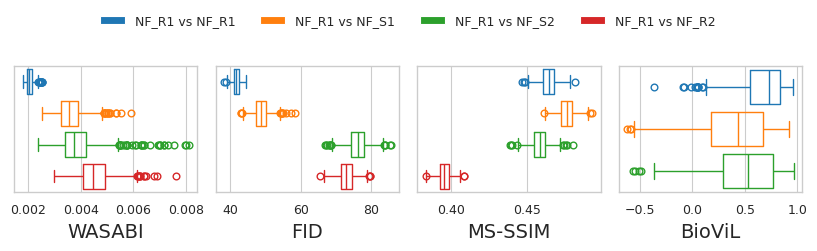

In [40]:
plot_between_models(
    conditions_list=[
        "Cheff-NF",
        "Roentgen-NF",
        "Cheff-Card",
        "Roentgen-Card",
        "CheXpert-NF",
    ],
    title="",
)

- Synthetic datasets exhibit greater morphometric deviation than the null splits (mimic nc nv mimic nc).

- However, both synthetic cohorts remain anatomically closer to MIMIC-CXR than Chexpert​

- Synthetic images reproduce training-domain anatomical statistics within natural inter-dataset variability.

- RoentGen shows larger FID deviation but moderate morphometric deviation 

### Between Groups (real vs synthetic)-Within Condition (Cardiomegaly vs Cardiomegaly)

In [41]:
"""Rearrage the data for plotting"""

# Labels
short_names = ["Card vs Card", "Card vs Cheff", "Card vs Roentgen", "Card vs CheXpert"]
palette = "Set2"
## WASABI distances
wasabi = comparison_df[
    [
        "real_vs_real_cardiomegaly",
        "real_vs_cheff_cardiomegaly",
        "real_vs_roentgen_cardiomegaly",
        # "real_no_finding_vs_cheff_cardiomegaly",
        # "real_no_finding_vs_roentgen_cardiomegaly",
        "real_vs_chexpert_cardiomegaly",
    ]
]
wasabi.columns = short_names

# FID distances
fid = pd.DataFrame(
    {
        "Card vs Card": fid_results["real_vs_real__cardiomegaly"]["fid_scores"],
        "Card vs Cheff": fid_results["real_vs_cheff__cardiomegaly"]["fid_scores"],
        "Card vs Roentgen": fid_results["real_vs_roentgen__cardiomegaly"]["fid_scores"],
        # "Cheff-Card":  fid_results["real_vs_cheff__no_finding_cardiomegaly"]["fid_scores"],
        # "Roentgen-Card":  fid_results["real_vs_roentgen__no_finding_cardiomegaly"]["fid_scores"],
        "Card vs CheXpert": fid_results["real_vs_chexpert__cardiomegaly"]["fid_scores"],
    }
)

mssim = pd.DataFrame(
    {
        "Card vs Card": mssim_results["real_vs_real__cardiomegaly"]["ms_ssim_scores"],
        "Card vs Cheff": mssim_results["real_vs_cheff__cardiomegaly"]["ms_ssim_scores"],
        "Card vs Roentgen": mssim_results["real_vs_roentgen__cardiomegaly"][
            "ms_ssim_scores"
        ],
        # "Cheff-Card":  mssim_results["real_vs_cheff__no_finding_cardiomegaly"]["ms_ssim_scores"],
        # "Roentgen-Card":  mssim_results["real_vs_roentgen__no_finding_cardiomegaly"]["ms_ssim_scores"],
        "Card vs CheXpert": mssim_results["real_vs_chexpert__cardiomegaly"][
            "ms_ssim_scores"
        ],
    }
)


biovil = pd.DataFrame(
    {
        "Card vs Card": biomedvil_results["real__cardiomegaly"]["clip_scores"][:400],
        "Card vs Cheff": biomedvil_results["real_vs_cheff__cardiomegaly"][
            "clip_scores"
        ][:400],
        "Card vs Roentgen": biomedvil_results["real_vs_roentgen__cardiomegaly"][
            "clip_scores"
        ][:400],
    }
)

- All the metrics indicate Cheff's `cardiomegaly` images are distibutionaly more similar to real cardiomegaly images.
- The `WASABI` metrics has a very small margin but shows a clear separation.
- `FID` in the other hand indicates Cheff is significantly more similar to the real dataset.

# What about other conditions.

In [42]:
pe_cases_real = measurement_df_real[
    measurement_df_real["prompt"].str.contains(
        "with pleural effusion", na=False, case=False
    )
].drop(columns="prompt")

atelectasis_cases_real = measurement_df_real[
    measurement_df_real["prompt"].str.contains("with atelectasis", na=False, case=False)
].drop(columns="prompt")

lung_op_cases_real = measurement_df_real[
    measurement_df_real["prompt"].str.contains(
        "with lung opacity", na=False, case=False
    )
].drop(columns="prompt")

pe_cases_real.info()

<class 'pandas.core.frame.DataFrame'>
Index: 675 entries, 61 to 15608
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CTR              675 non-null    float64
 1   Lung_L_Area      675 non-null    float64
 2   Lung_R_Area      675 non-null    float64
 3   Clavicle_L_Area  675 non-null    float64
 4   Clavicle_R_Area  675 non-null    float64
 5   Scapula_L_Area   675 non-null    float64
 6   Scapula_R_Area   675 non-null    float64
 7   Trachea_Area     675 non-null    float64
 8   Spine_Area       675 non-null    float64
 9   Diaphragm_Area   675 non-null    float64
dtypes: float64(10)
memory usage: 58.0 KB


In [43]:
real_pe_cases = pe_cases_real.to_numpy()
real_atelectasis_cases = atelectasis_cases_real.to_numpy()
real_lung_op_cases = lung_op_cases_real.to_numpy()

In [44]:
print(real_pe_cases.shape)
print(real_lung_op_cases.shape)
print(real_atelectasis_cases.shape)

(675, 10)
(545, 10)
(861, 10)


In [45]:
n = 150
nc_vs_pe = run_ctr_wasabi(
    real_no_finding_ctr,
    real_pe_cases,
    # n_samples=min(real_no_finding_ctr.shape[0], real_pleural_effusion_ctr.shape[0]),
    n_samples=n,
)  # comparing no finding vs pleural effusion in the real dataset

nc_vs_lo = run_ctr_wasabi(
    real_no_finding_ctr,
    real_lung_op_cases,
    # n_samples=min(real_no_finding_ctr.shape[0], real_pleural_effusion_ctr.shape[0]),
    n_samples=n,
)  # comparing no finding vs lung opacity in the real dataset

nc_vs_atelectasis = run_ctr_wasabi(
    real_no_finding_ctr,
    real_atelectasis_cases,
    # n_samples=min(real_no_finding_ctr.shape[0], real_pleural_effusion_ctr.shape[0]),
    n_samples=n,
)  # comparing no finding vs atelectasis in the real dataset

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 570.01it/s]


In [46]:
data = pd.DataFrame(
    {
        "NF_R1": nc_vs_nc,
        "CM_R1": nc_vs_c,
        "PE_R1": nc_vs_pe,
        "LO_R1": nc_vs_lo,
        "AC_R1": nc_vs_atelectasis,
    }
)
data_melt = data.melt(var_name="Comparison", value_name="Wasserstein Distance")
# data_melt["ID"] = list(range(len(data_melt)))
# data_melt["Wasserstein Distance"] = data_melt["Wasserstein Distance"] * 1000.
data_melt.head()

,Comparison,Wasserstein Distance
0,NF_R1,0.002136
1,NF_R1,0.001949
2,NF_R1,0.002004
3,NF_R1,0.002244
4,NF_R1,0.002100


In [47]:
data.isna().sum()

NF_R1    0
CM_R1    0
PE_R1    0
LO_R1    0
AC_R1    0
dtype: int64

In [48]:
data.describe()

,NF_R1,CM_R1,PE_R1,LO_R1,AC_R1
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.002057,0.014553,0.016240,0.009908,0.014686
std,0.000124,0.001498,0.002081,0.001382,0.002070
min,0.001797,0.009870,0.009688,0.006179,0.008804
25%,0.001967,0.013513,0.014784,0.008883,0.013300
50%,0.002041,0.014505,0.016100,0.009818,0.014593
75%,0.002136,0.015546,0.017581,0.010869,0.015985
max,0.002537,0.020229,0.022691,0.015918,0.022816


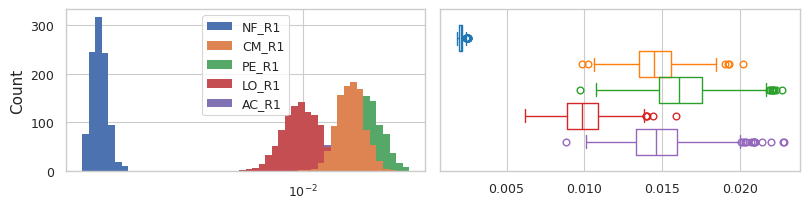

In [50]:
#plt.figure(figsize=(8.2, 2.2))
fig, axs = plt.subplots(1,2,figsize=(8.2, 2.2))
# plt.title("CTR-Wasserstein distances for different pathologies", fontsize=16, fontweight="bold")
sns.histplot(data=data, log_scale=True, bins=50, linewidth=0, alpha=1, ax=axs[0])
sns.boxplot(
    data=data_melt,
    x="Wasserstein Distance",
    hue="Comparison",
    log_scale=False,
    palette="tab10",
    fill=False,
    orient="h",
    legend=True,
    linewidth=1.0,
    ax=axs[1]
)
#plt.xlabel("Wasserstein Distance", fontsize=14)
plt.legend(fontsize=10)
axs[0].set_xlabel("", fontsize=14)
axs[1].set_xlabel("", fontsize=14)
axs[1].legend_.remove()
plt.tight_layout()
plt.savefig("ctr_wasserstein_pathologies.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [52]:
delta = data["CM_R1"] - data["LO_R1"]
delta = delta.to_numpy()
print("Mean of delta:", delta.mean())
print("CI%95", np.percentile(delta, [2.5, 97.5]))

Mean of delta: 0.004645726721518338
CI%95 [0.00062094 0.00840103]


In [53]:
delta = data["CM_R1"] - data["PE_R1"]
delta = delta.to_numpy()
print("Mean of delta:", delta.mean())
print("CI%95", np.percentile(delta, [2.5, 97.5]))

Mean of delta: -0.0016863429823657148
CI%95 [-0.00676812  0.00298046]


In [54]:
delta = data["CM_R1"] - data["AC_R1"]
delta = delta.to_numpy()
print("Mean of delta:", delta.mean())
print("CI%95", np.percentile(delta, [2.5, 97.5]))

Mean of delta: -0.0001330174488986602
CI%95 [-0.00529964  0.00456527]
